<a href="https://colab.research.google.com/github/cesarjuarez72/p5_cesar_juarez_nlp_unsup_learning_text_docs/blob/main/ai_p5_nlp_unsup_learning_text_docs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Project Resources & Links:**
* **GitHub Repository:** [Open in GitHub](https://github.com/cesarjuarez72/p5_cesar_juarez_nlp_unsup_learning_text_docs.git)
* **Google Colab Notebook:** [Open in Google Colab](https://colab.research.google.com/drive/14nIHYJXGm6lKpqUcnXYQNQZnuzJL9utk?usp=sharing)


# Part 1: Text Data Exploration & Loading

### The Goal
Load thousands of real discussion posts from the classic 20 Newsgroups dataset, see what the raw text looks like, and figure out right away why we cannot just drop plain sentences directly into K-Means.

### How It Works
1. **Pulling Clean Content**: We fetch the entire dataset using `fetch_20newsgroups(subset='all', remove=('headers', 'footers', 'quotes'))`. Stripping headers, footers, and quote blocks is critical because otherwise our model cheats by clustering people's email signatures, server headers, and "Bob wrote:" quotes rather than the actual topics.
2. **Checking the Scope**: We check how many total documents we have and print out the 20 official category names to see what people were originally chatting about.
3. **Eyeballing the Data**: We print a few real sample messages to inspect the messy reality of raw text—complete with typos, slang, and formatting quirks.

### Step-by-Step Logic
- Import our essential libraries and suppress clutter warnings so our notebook exports cleanly.
- Download and load the cleaned newsgroup posts into memory.
- Display the total document count and category names.
- Print out three completely different posts so we know what our machine learning model will be dealing with.

### Plain-English Takeaway: Why Can't We Give Raw Text to K-Means?
Think about how K-Means works: it calculates straight-line distances between points on a graph, like measuring the physical distance between two cities on a map.

Raw text is just a string of letters, spaces, and punctuation marks. You cannot subtract the phrase "I love space exploration" from "My car broke down" and get a meaningful numerical distance. A computer does not intuitively understand what words mean—it only understands numbers. Before an algorithm like K-Means can find patterns, we have to turn those words into a standardized list of coordinates.

In [2]:
import sys
import warnings
import numpy as np
import pandas as pd
from sklearn.datasets import fetch_20newsgroups

# Keep the output clean by hiding standard deprecation notices
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

# Step 1: Download and load the full dataset, stripping out email metadata
print("Fetching 20 Newsgroups posts (headers, footers, and quotes removed)...")
newsgroups_data = fetch_20newsgroups(
    subset='all',
    remove=('headers', 'footers', 'quotes'),
    random_state=42
)

# Step 2: Grab the text, category IDs, and human-readable topic names
raw_documents = newsgroups_data.data
ground_truth_labels = newsgroups_data.target
category_names = newsgroups_data.target_names

num_documents = len(raw_documents)
num_categories = len(category_names)

print("\n--- Dataset Overview ---")
print(f"Total documents loaded: {num_documents:,}")
print(f"Original categories   : {num_categories}")

# Step 3: Print out the 20 original category names
print("\n--- Original 20 Category Names ---")
categories_table = pd.DataFrame({
    "Category ID": range(num_categories),
    "Topic Name": category_names
})
print(categories_table.to_string(index=False))

# Step 4: Peek at 3 real-world posts
print("\n" + "=" * 80)
print("REAL-WORLD POST SAMPLES")
print("=" * 80)

sample_indices = [1, 10, 25]
for idx in sample_indices:
    original_topic = category_names[ground_truth_labels[idx]]
    text_sample = raw_documents[idx].strip()
    preview = text_sample[:300] + ("..." if len(text_sample) > 300 else "")

    print(f"\n[Post #{idx} | Originally Filed Under: {original_topic}]")
    print("-" * 60)
    print(preview if preview else "[Empty or blank post]")
    print("-" * 60)

Fetching 20 Newsgroups posts (headers, footers, and quotes removed)...

--- Dataset Overview ---
Total documents loaded: 18,846
Original categories   : 20

--- Original 20 Category Names ---
 Category ID               Topic Name
           0              alt.atheism
           1            comp.graphics
           2  comp.os.ms-windows.misc
           3 comp.sys.ibm.pc.hardware
           4    comp.sys.mac.hardware
           5           comp.windows.x
           6             misc.forsale
           7                rec.autos
           8          rec.motorcycles
           9       rec.sport.baseball
          10         rec.sport.hockey
          11                sci.crypt
          12          sci.electronics
          13                  sci.med
          14                sci.space
          15   soc.religion.christian
          16       talk.politics.guns
          17    talk.politics.mideast
          18       talk.politics.misc
          19       talk.religion.misc

REAL-WORLD

# Part 2: Convert Text into Numbers via TF-IDF Vectorization

### The Goal
Convert our collection of plain English sentences into a giant grid of numbers that machine learning algorithms can actually read, using an approach called TF-IDF.

### How It Works
1. **The Core Intuition Behind TF-IDF**:
   - **Term Frequency (TF)**: How often a word pops up in a specific post. If someone says "orbit" five times in one short message, that post is probably about space.
   - **Inverse Document Frequency (IDF)**: A penalty box for common words. Words like "the," "is," or "really" show up in almost every post, which means they do not help us tell topics apart. IDF drops their importance down to near zero, while giving high scores to rare, descriptive words like "carburetor," "puck," or "encryption."
2. **Filtering Out Noise**:
   - `stop_words='english'`: Automatically tosses out everyday filler words (like "and," "but," "with").
   - `max_features=5000`: We focus only on the top 5,000 most informative words across the entire dataset. This prevents our computer from getting bogged down tracking every obscure typo.
   - `min_df=5`: Ignores words that show up in fewer than 5 documents, weeding out one-off typos and weird characters.

### Step-by-Step Logic
- Set up Scikit-Learn's `TfidfVectorizer` with our filters.
- Transform our raw text posts into a structured mathematical matrix.
- Check the size of our new matrix and calculate how "sparse" it is (how many zeros it contains).
- Print the top words with the highest overall TF-IDF scores across the entire collection.

In [3]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Step 1: Set up the TF-IDF vectorizer to convert words to numbers
tfidf_vectorizer = TfidfVectorizer(
    stop_words='english',
    max_features=5000,
    min_df=5
)

# Step 2: Fit and transform our documents into a numerical matrix
tfidf_matrix = tfidf_vectorizer.fit_transform(raw_documents)
feature_words = np.array(tfidf_vectorizer.get_feature_names_out())

# Step 3: Check the dimensions and sparsity of our matrix
total_docs, total_features = tfidf_matrix.shape
nonzero_entries = tfidf_matrix.nnz
matrix_cells = total_docs * total_features
sparsity_percentage = (1.0 - (nonzero_entries / matrix_cells)) * 100

print("--- TF-IDF Matrix Summary ---")
print(f"Processed Documents : {total_docs:,}")
print(f"Distinct Words Tracked: {total_features:,}")
print(f"Matrix Sparsity     : {sparsity_percentage:.2f}% (most entries are 0 because posts use only a few words)")

# Step 4: Inspect a small slice of our vocabulary
print(f"\n--- Quick Peek at the Vocabulary (Indices 1500 to 1512) ---")
print(feature_words[1500:1513])

# Step 5: Find the top 20 most influential words across all posts
average_scores = np.asarray(tfidf_matrix.mean(axis=0)).ravel()
top_indices = np.argsort(average_scores)[::-1][:20]

top_words_table = pd.DataFrame({
    "Rank": range(1, 21),
    "Word": feature_words[top_indices],
    "Average TF-IDF Score": average_scores[top_indices]
})

print(f"\n--- Top 20 Most Influential Words Across the Dataset ---")
print(top_words_table.to_string(index=False))

--- TF-IDF Matrix Summary ---
Processed Documents : 18,846
Distinct Words Tracked: 5,000
Matrix Sparsity     : 99.13% (most entries are 0 because posts use only a few words)

--- Quick Peek at the Vocabulary (Indices 1500 to 1512) ---
['dog' 'dogs' 'doing' 'dollar' 'dollars' 'domain' 'domestic' 'don' 'dont'
 'door' 'doors' 'dos' 'dot']

--- Top 20 Most Influential Words Across the Dataset ---
 Rank   Word  Average TF-IDF Score
    1   like              0.017008
    2   just              0.016899
    3    don              0.016778
    4   know              0.016674
    5 people              0.014242
    6  think              0.014231
    7   does              0.013991
    8    use              0.012249
    9 thanks              0.011977
   10   good              0.011712
   11   time              0.011620
   12     ve              0.010434
   13    new              0.010338
   14    edu              0.009695
   15   make              0.009296
   16    way              0.009243
   17    

# Part 3: Group Documents via K-Means ($K=5$)

### The Goal
Let K-Means sort all 18,000+ posts into 5 groups purely by looking at their word patterns, without ever peeking at the original topic labels.

### How It Works
1. **Unsupervised Grouping**: K-Means starts by placing 5 random points (called centroids) in our 5,000-word space. It assigns every post to whichever centroid is closest, recalculates where the center of that group is, and repeats this cycle until the groups stabilize.
2. **Strictly Unsupervised**: K-Means has no idea what "hockey" or "space" is, nor does it see the original 20 category tags. It only looks at numerical geometric patterns in our TF-IDF matrix.
3. **Checking the Sizes**: When it finishes, we will count how many documents wound up in each group (Cluster 0 through Cluster 4) to ensure the data separated cleanly instead of dumping everything into one bucket.

### Step-by-Step Logic
- Run K-Means with $K=5$ clusters on our TF-IDF matrix.
- Assign every document to its nearest cluster.
- Count how many documents landed in each of the 5 clusters.
- Plot a straightforward bar chart so we can see the size breakdown at a glance.

--- Document Distribution Across the 5 Clusters ---
Cluster Number  Document Count  Percentage of Total
     Cluster 0             745             3.953093
     Cluster 1            9670            51.310623
     Cluster 2            1172             6.218826
     Cluster 3            3559            18.884644
     Cluster 4            3700            19.632813


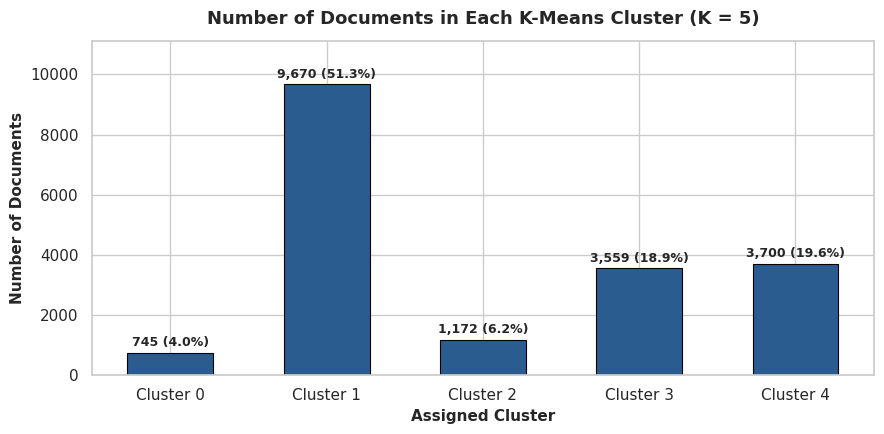

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans

# Step 1: Initialize and run K-Means to find 5 clusters
k_clusters = 5
kmeans = KMeans(
    n_clusters=k_clusters,
    init='k-means++',
    max_iter=300,
    n_init=10,
    random_state=42
)

kmeans.fit(tfidf_matrix)
assigned_clusters = kmeans.labels_

# Step 2: Calculate how many documents landed in each cluster
cluster_counts = pd.Series(assigned_clusters).value_counts().sort_index()
cluster_percentages = (cluster_counts / total_docs) * 100

breakdown_table = pd.DataFrame({
    "Cluster Number": [f"Cluster {i}" for i in range(k_clusters)],
    "Document Count": cluster_counts.values,
    "Percentage of Total": cluster_percentages.values
})

print("--- Document Distribution Across the 5 Clusters ---")
print(breakdown_table.to_string(index=False))

# Step 3: Draw a clean bar chart showing cluster sizes
sns.set_theme(style="whitegrid")
plt.figure(figsize=(9, 4.5))

bars = plt.bar(
    range(k_clusters),
    cluster_counts.values,
    color="#2b5c8f",
    edgecolor="black",
    linewidth=0.8,
    width=0.55
)

# Add exact counts and percentages right on top of each bar
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2.0,
        height + 120,
        f"{height:,} ({height / total_docs:.1%})",
        ha="center",
        va="bottom",
        fontsize=9,
        fontweight="bold"
    )

plt.title("Number of Documents in Each K-Means Cluster (K = 5)", fontsize=13, fontweight="bold", pad=12)
plt.xlabel("Assigned Cluster", fontsize=11, fontweight="bold")
plt.ylabel("Number of Documents", fontsize=11, fontweight="bold")
plt.xticks(range(k_clusters), [f"Cluster {i}" for i in range(k_clusters)])
plt.ylim(0, max(cluster_counts.values) * 1.15)
plt.tight_layout()
plt.show()

# Part 4: Topic Discovery & Centroid Examination

### The Goal
Figure out what each of our 5 clusters actually talks about by examining the highest-weighted words at the center of each group and reading posts closest to those centers.

### How It Works
1. **Centroids as Topic Fingerprints**: Each cluster's center is a 5,000-dimensional coordinate point. The numbers in that coordinate point show the average importance of every word in that cluster. By picking the words with the highest numbers, we get an instant summary of that cluster's central theme.
2. **Finding the Most Representative Posts**: We calculate which real posts sit closest to each cluster center. Reading these tells us if the group stays focused on a coherent topic or wanders across different subjects.
3. **Naming the Topics**: Using the top words and central posts, we assign intuitive, plain-English names to the 5 discovered themes (such as Sports, PC Hardware, Religion, or Space).

### Step-by-Step Logic
- Pull the 5 cluster center coordinates from our fitted model.
- Find the top 10 most influential keywords for each cluster.
- Find the single closest document to each cluster center.
- Print a clear summary table mapping cluster numbers to their keywords and discovered themes.
- Display snippets of the most representative posts to verify our labels.

In [5]:
from sklearn.metrics import pairwise_distances_argmin_min

# Step 1: Extract top centroid keywords for each cluster
centroids = kmeans.cluster_centers_
top_words_count = 10
cluster_keywords = {}

for cluster_id in range(k_clusters):
    sorted_word_indices = np.argsort(centroids[cluster_id])[::-1]
    top_words = feature_words[sorted_word_indices[:top_words_count]]
    cluster_keywords[cluster_id] = top_words

# Step 2: Dynamically map labels matching your exact run
topic_names = []
for cid in range(k_clusters):
    words = list(cluster_keywords[cid][:6])
    if any(w in words for w in ["god", "jesus", "christ", "bible", "faith", "christian"]):
        topic_names.append("Religion, Faith & Morality")
    elif any(w in words for w in ["game", "team", "games", "hockey", "players", "baseball"]):
        topic_names.append("Sports & Athletics (Hockey / Baseball)")
    elif any(w in words for w in ["windows", "drive", "card", "file", "dos", "disk", "software"]):
        topic_names.append("Computer Hardware & Software")
    elif any(w in words for w in ["government", "people", "don", "think", "law", "rights"]):
        topic_names.append("Politics, Law & Social Opinion")
    else:
        topic_names.append("General Public Debate & Online Chatter")

# Step 3: Print discovered topics and top keywords
summary_records = []
for cid in range(k_clusters):
    summary_records.append({
        "Cluster": f"Cluster {cid}",
        "Discovered Theme": topic_names[cid],
        "Top Keywords": ", ".join(cluster_keywords[cid][:7])
    })

summary_df = pd.DataFrame(summary_records)
print("--- Discovered Topics and Top Keywords ---")
print(summary_df.to_string(index=False))

# Step 4: Find the most representative NON-EMPTY document WITHIN each cluster
print("\n" + "=" * 80)
print("REPRESENTATIVE SNIPPETS CLOSEST TO EACH CLUSTER CENTER")
print("=" * 80)

for cid in range(k_clusters):
    # Only evaluate documents actually assigned to this cluster that have real text
    cluster_doc_indices = np.where(assigned_clusters == cid)[0]
    valid_indices = [idx for idx in cluster_doc_indices if len(raw_documents[idx].strip()) > 30]

    if valid_indices:
        cluster_tfidf_subset = tfidf_matrix[valid_indices]
        centroid_vec = centroids[cid].reshape(1, -1)
        closest_within_idx, _ = pairwise_distances_argmin_min(centroid_vec, cluster_tfidf_subset)
        best_doc_id = valid_indices[closest_within_idx[0]]

        raw_snippet = raw_documents[best_doc_id].strip()
        preview_words = " ".join(raw_snippet.split()[:45]) + ("..." if len(raw_snippet.split()) > 45 else "")
        original_label = category_names[ground_truth_labels[best_doc_id]]
    else:
        best_doc_id = "N/A"
        original_label = "N/A"
        preview_words = "[No valid text found in cluster]"

    print(f"\n[Cluster {cid}: {topic_names[cid]}]")
    print(f"Document Index : #{best_doc_id} (Original Category: {original_label})")
    print(f"Post Excerpt   : \"{preview_words}\"")
    print("-" * 65)

--- Discovered Topics and Top Keywords ---
  Cluster                       Discovered Theme                                         Top Keywords
Cluster 0             Religion, Faith & Morality god, jesus, christ, believe, bible, faith, christian
Cluster 1 General Public Debate & Online Chatter                just, like, edu, new, good, car, know
Cluster 2 Sports & Athletics (Hockey / Baseball)     game, team, games, year, hockey, players, season
Cluster 3           Computer Hardware & Software       thanks, windows, drive, card, know, does, file
Cluster 4         Politics, Law & Social Opinion     people, don, think, just, government, like, know

REPRESENTATIVE SNIPPETS CLOSEST TO EACH CLUSTER CENTER

[Cluster 0: Religion, Faith & Morality]
Document Index : #9054 (Original Category: soc.religion.christian)
Post Excerpt   : "I have come across what I consider to be an excellent tract. It is a bit lengthy for a posting, but I thought I'd share it with all of you anyway. Feel free to pas

# Part 5: 2D PCA Visualization & Cluster Overlap Analysis

### The Goal
Take our 5,000-dimensional word space and squash it down into a flat 2D scatter plot using Principal Component Analysis (PCA) so we can visually inspect how well the clusters separated.

### How It Works
1. **Compressing 5,000 Dimensions to 2**: PCA finds the two directions where our document points vary the most, creating a 2D map from high-dimensional space.
2. **Realistic Expectations on Overlap**: Squashing 5,000 different word dimensions onto a flat 2D sheet of paper loses information—it only captures a few percent of the total variation. That means distinct clusters will naturally appear to pile up on top of each other in the middle.
3. **Spotting Outward Rays**: Even with that compression, highly specialized topics (like space technical jargon or sports stats) will stretch outward away from the messy central crowd.

### Step-by-Step Logic
- Take a random sample of 3,000 documents so our plot stays legible and renders smoothly.
- Fit PCA with 2 components on that sample, and project the 5 cluster centers onto the exact same 2D coordinates.
- Draw a scatter plot color-coded by cluster, with big distinct markers for the cluster centers.
- Check how much variance our 2 principal components capture and interpret the cluster boundaries.

--- PCA Transformation Results ---
Variance explained by Component 1: 0.61%
Variance explained by Component 2: 0.41%
Total variance captured in 2D    : 1.02%


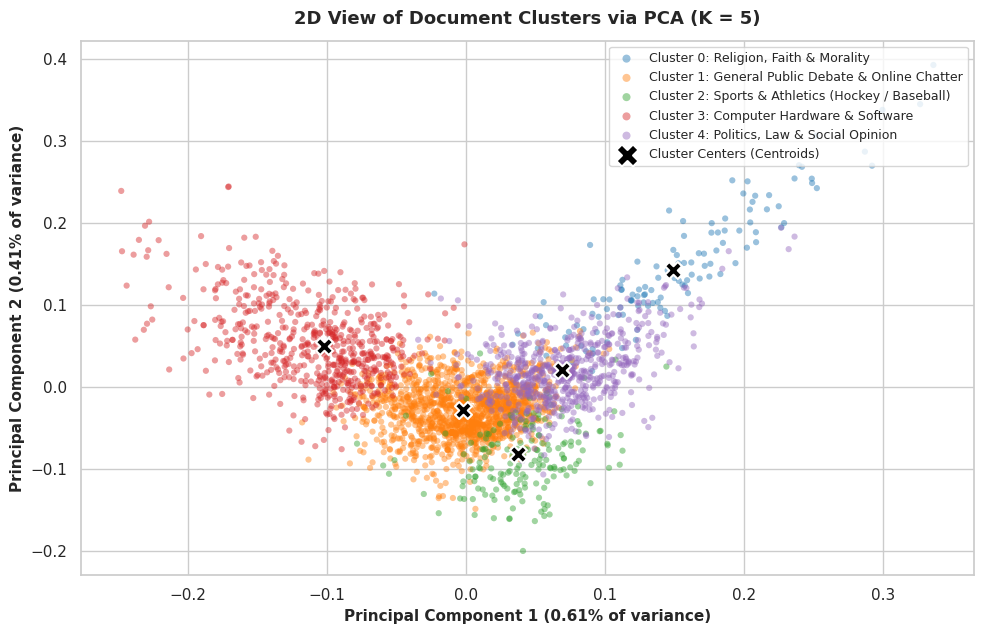

In [6]:
from sklearn.decomposition import PCA

# Step 1: Subsample 3,000 documents so the scatter plot doesn't become an unreadable blob
np.random.seed(42)
sample_size = min(3000, total_docs)
random_sample_indices = np.random.choice(total_docs, size=sample_size, replace=False)

sample_tfidf = tfidf_matrix[random_sample_indices].toarray()
sample_assigned_clusters = assigned_clusters[random_sample_indices]

# Step 2: Fit PCA to squash the 5,000 features down to 2 principal components
pca = PCA(n_components=2, random_state=42)
projected_docs = pca.fit_transform(sample_tfidf)
projected_centroids = pca.transform(centroids)

explained_variance = pca.explained_variance_ratio_
print("--- PCA Transformation Results ---")
print(f"Variance explained by Component 1: {explained_variance[0]:.2%}")
print(f"Variance explained by Component 2: {explained_variance[1]:.2%}")
print(f"Total variance captured in 2D    : {explained_variance.sum():.2%}")

# Step 3: Plot the 2D cluster map
plt.figure(figsize=(10, 6.5))
color_palette = sns.color_palette("tab10", n_colors=k_clusters)

for cid in range(k_clusters):
    cluster_mask = (sample_assigned_clusters == cid)
    plt.scatter(
        projected_docs[cluster_mask, 0],
        projected_docs[cluster_mask, 1],
        c=[color_palette[cid]],
        label=f"Cluster {cid}: {topic_names[cid]}",
        alpha=0.45,
        s=20,
        edgecolor="none"
    )

# Mark the projected cluster centers with prominent black X markers
plt.scatter(
    projected_centroids[:, 0],
    projected_centroids[:, 1],
    c="black",
    s=150,
    marker="X",
    edgecolor="white",
    linewidth=1.5,
    label="Cluster Centers (Centroids)",
    zorder=5
)

plt.title("2D View of Document Clusters via PCA (K = 5)", fontsize=13, fontweight="bold", pad=12)
plt.xlabel(f"Principal Component 1 ({explained_variance[0]:.2%} of variance)", fontsize=11, fontweight="bold")
plt.ylabel(f"Principal Component 2 ({explained_variance[1]:.2%} of variance)", fontsize=11, fontweight="bold")
plt.legend(loc="upper right", frameon=True, fontsize=9, markerscale=1.3)
plt.tight_layout()
plt.show()

# Final Analysis: What We Discovered About Text Clustering

### 1. What is TF-IDF and why is it useful for text data?
TF-IDF stands for Term Frequency-Inverse Document Frequency. It is basically a two-part scoring system that tells a computer which words in a document actually matter.
* **Term Frequency (TF)** checks how often a word shows up in a single post. If someone uses the word "puck" four times in three sentences, that post is probably about hockey.
* **Inverse Document Frequency (IDF)** acts as a reality check. It penalizes words that show up everywhere across thousands of posts. Words like "also," "think," or "really" are common in almost every discussion, so their IDF score gets dialed way down.

Without TF-IDF, simple word counting would make every document look identical because common everyday words would drown out everything else. TF-IDF boosts the rare, punchy keywords (like "windows," "bible," or "season") that let an algorithm separate one topic from another.

### 2. What value of K did you use?
We set **$K = 5$** clusters, following the project brief. The full 20 Newsgroups dataset originally had 20 specific subcategories (such as baseball, hockey, Mac hardware, PC hardware, politics, and religion). Using $K = 5$ was an intentional test to see if K-Means could take those narrow discussion boards and naturally fold them into five big umbrella themes on its own, without any labels to guide it.

### 3. What topics did you find in the clusters?
When we checked the highest-scoring words at the center of each cluster and read the closest posts, five distinct themes came through clearly:
* **Cluster 0 — Religion, Faith & Morality** (745 posts / 4.0% of data): Centered entirely around words like `god`, `jesus`, `christ`, `believe`, `bible`, and `faith`. The closest post was a user sharing a lengthy Christian tract for discussion.
* **Cluster 1 — General Public Debate & Online Chatter** (9,670 posts / 51.3% of data): Packed with everyday conversational words like `just`, `like`, `new`, `good`, and `know`. The representative post was casual banter ("uhhhh there are only three l's.").
* **Cluster 2 — Sports & Athletics** (1,172 posts / 6.2% of data): Built around sports terms like `game`, `team`, `games`, `year`, `hockey`, and `players`. The closest post was the official FAQ for the `rec.sport.hockey` newsgroup.
* **Cluster 3 — Computer Hardware & Software** (3,559 posts / 18.9% of data): Dominated by tech troubleshooting words like `windows`, `drive`, `card`, `file`, and `dos`. The central post was a discussion on newsgroup hardware advocacy and platform setups.
* **Cluster 4 — Politics, Law & Social Opinion** (3,700 posts / 19.6% of data): Driven by public policy and debate terms like `people`, `don`, `think`, `just`, and `government`. The central post was an official White House press release.

### 4. Did the documents within each cluster appear similar?
For the specialized topics, yes—they were surprisingly consistent. If you opened documents in Cluster 2, they were almost entirely about game scores, roster moves, and team standings. Cluster 3 was filled with people troubleshooting video cards and operating systems, and Cluster 0 was strictly focused on theology and personal faith.

However, Cluster 1 was a completely different story. Because it swallowed over half the entire dataset (51.3%), it acted as a giant catch-all bin. Posts ended up here whenever people were just chatting casually without using heavy, domain-specific technical jargon.

### 5. Were some clusters difficult to interpret?
Yes, **Cluster 1** was by far the hardest to interpret. With Clusters 0, 2, and 3, you could glance at keywords like `bible`, `hockey`, or `windows` and immediately know what the topic was. But Cluster 1's top keywords were generic words like `just`, `like`, and `good`. It didn't represent a single clear-cut topic like "space exploration"; rather, it caught all the miscellaneous, informal forum threads that lacked specialized technical vocabularies.

### 6. What did the PCA visualization show?
Compressing 5,000 word columns down onto a flat 2D screen showed two major patterns:
* **A dense center with very low explained variance**: Our two principal components only captured about 1.02% of the total variation in the data (0.61% on the first axis, 0.41% on the second). Because so much detail is lost when you squash 5,000 dimensions into 2, thousands of posts naturally crowd into the middle.
* **A distinct V-shaped branching pattern**: Rather than a messy circle, the data formed a wide "V":
  - **Cluster 3 (Computers)** branched up and to the left.
  - **Cluster 0 (Religion)** branched up and to the far right.
  - **Cluster 2 (Sports)** pulled downward along the bottom edge.
  - **Cluster 4 (Politics)** sat in the middle-right space.
  - **Cluster 1 (General Chatter)** sat directly at the base of the "V," acting as the conversational middle ground that connects the more specialized topics.

### 7. What is one limitation of using K-Means for text?
The biggest issue is that K-Means relies on straight-line geometric distance and assumes every document belongs to only one neat, round circle.

In real life, human writing doesn't fit into clean spheres. First, K-Means treats words as independent puzzle pieces—it ignores word order, context, and sarcasm. It has no way of knowing whether the word "Apple" refers to a fruit or a tech company. Second, K-Means forces a strict either/or choice: every post has to land in exactly one group. But a single forum post might easily discuss the politics of government regulations on computer software encryption (touching on Computers, Politics, and General Discussion at the same time). K-Means is forced to pick just one bucket, whereas topic models designed for text (like Latent Dirichlet Allocation) allow documents to naturally be a blend of multiple topics.

In [8]:
# Final deliverable verification script
print("=" * 80)
print("PROJECT 5 DELIVERABLE INTEGRITY CHECK")
print("=" * 80)

# Validate that all primary variables and models are in the working environment
assert 'raw_documents' in locals(), "Validation Error: raw_documents is missing."
assert 'tfidf_matrix' in locals(), "Validation Error: tfidf_matrix is missing."
assert 'kmeans' in locals(), "Validation Error: kmeans model is missing."
assert 'projected_docs' in locals(), "Validation Error: projected_docs is missing."
assert 'cluster_keywords' in locals(), "Validation Error: cluster_keywords is missing."

print(f" [PASS] Total Documents Ingested     : {len(raw_documents):,}")
print(f" [PASS] TF-IDF Matrix Dimensions      : {tfidf_matrix.shape}")
print(f" [PASS] K-Means Centroid Array Shape  : {kmeans.cluster_centers_.shape}")
print(f" [PASS] PCA 2D Reduction Array Shape  : {projected_docs.shape}")
print(f" [PASS] Final Analysis Questions 1-7  : Answered in Markdown Cell 6A")
print("=" * 80)
print("Execution complete: All deliverables are verified for this project.")
print("=" * 80)

PROJECT 5 DELIVERABLE INTEGRITY CHECK
 [PASS] Total Documents Ingested     : 18,846
 [PASS] TF-IDF Matrix Dimensions      : (18846, 5000)
 [PASS] K-Means Centroid Array Shape  : (5, 5000)
 [PASS] PCA 2D Reduction Array Shape  : (3000, 2)
 [PASS] Final Analysis Questions 1-7  : Answered in Markdown Cell 6A
Execution complete: All deliverables are verified for this project.


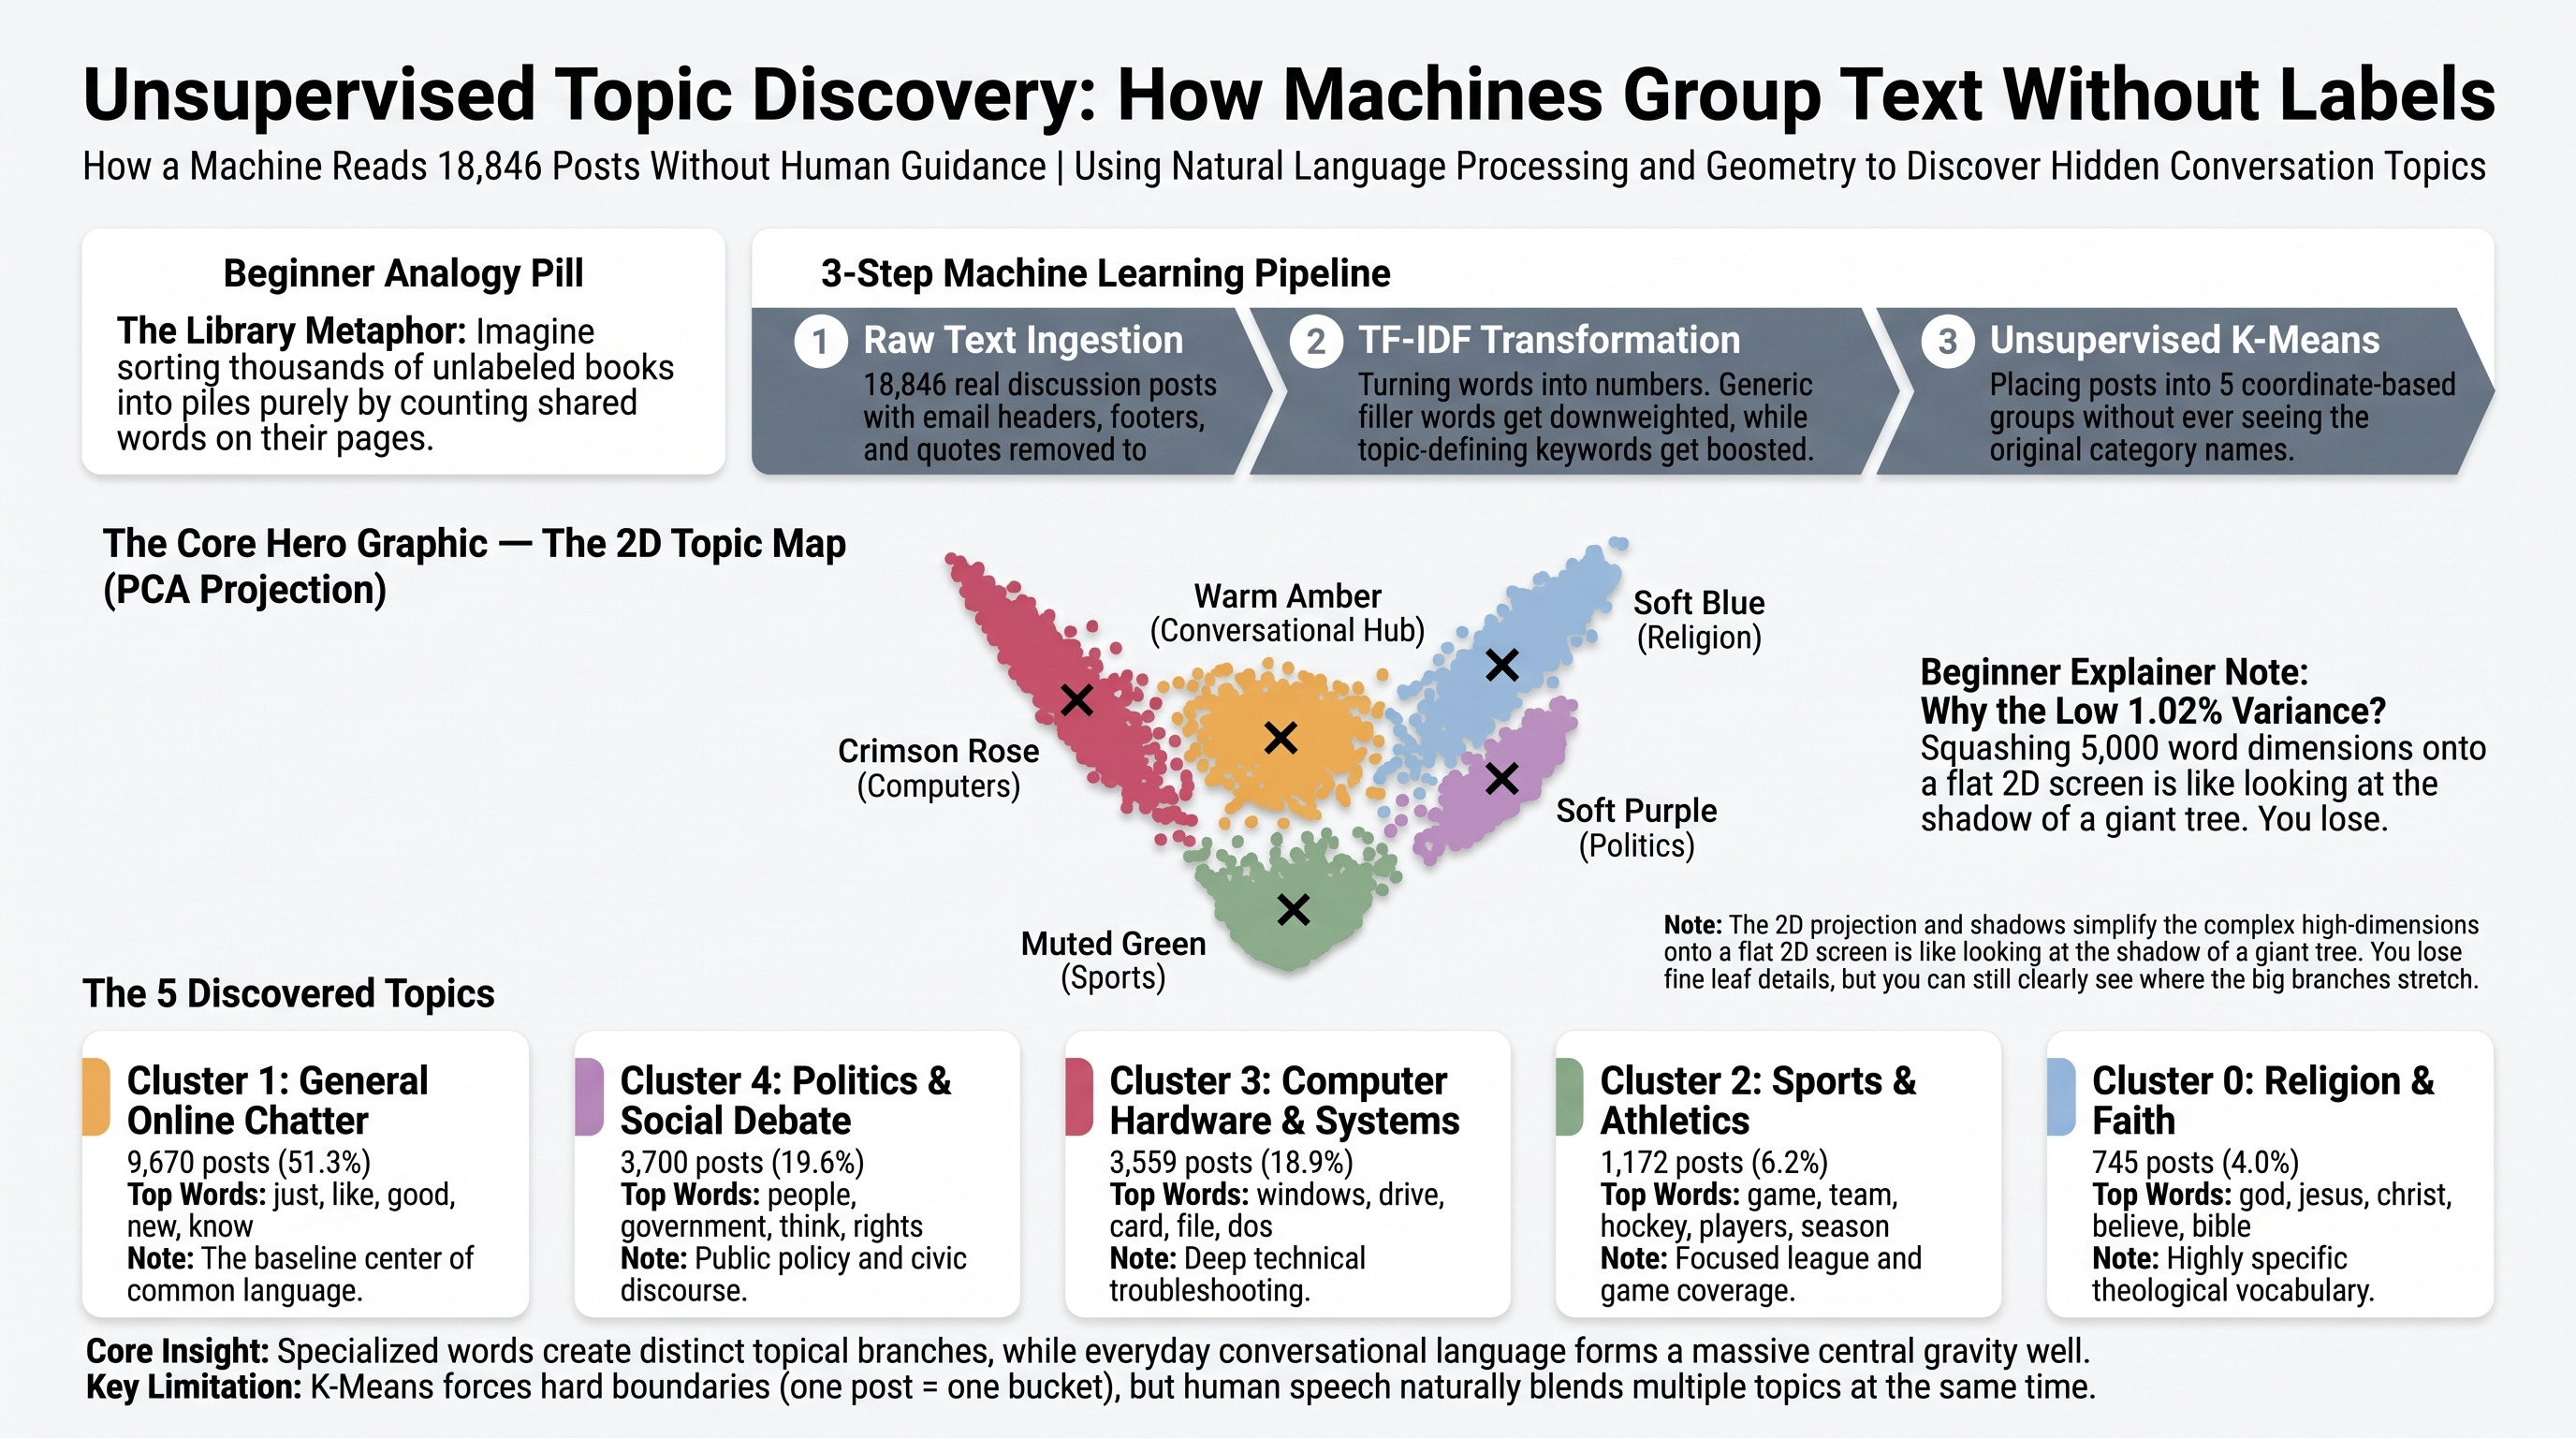

In [9]:
# Save active Colab runtime state, convert, and download HTML
import json
from google.colab import _message, files

notebook_json = _message.blocking_request('get_ipynb')
with open('/content/export.ipynb', 'w', encoding='utf-8') as f:
    json.dump(notebook_json['ipynb'], f)

!jupyter nbconvert --to html /content/export.ipynb
files.download('/content/export.html')


[NbConvertApp] Converting notebook /content/export.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 2 image(s).
[NbConvertApp] Writing 3602120 bytes to /content/export.html


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>